# Data analysis of the data gathered using places API




Load the restaurant dataset, from the google places API.

In [2]:
%matplotlib inline
import json

def load_json_file(db_file_name):
    with open(db_file_name, 'r', encoding='utf-8') as file:
        return json.load(file)

restaurants = load_json_file("../placesData/all_places1.json")["places"]



We want to find out what unique categories places have, so we can encode this information in the recommendation models.

## Analysing unique types

In [3]:
unique_types = {}

for rest in restaurants:
    for type in rest["types"]:
        if type in unique_types.keys():
            unique_types[type] = unique_types[type] + 1
        else:
            unique_types[type] = 1
            
unique_types

{'donut_shop': 2,
 'bakery': 107,
 'coffee_shop': 186,
 'cafe': 267,
 'dessert_shop': 132,
 'confectionery': 154,
 'food_store': 418,
 'store': 451,
 'food': 1732,
 'point_of_interest': 1844,
 'establishment': 1844,
 'breakfast_restaurant': 90,
 'wholesaler': 25,
 'restaurant': 1318,
 'sandwich_shop': 13,
 'tea_house': 72,
 'bar': 299,
 'buffet_restaurant': 31,
 'dessert_restaurant': 10,
 'chocolate_shop': 35,
 'candy_store': 53,
 'fast_food_restaurant': 102,
 'mexican_restaurant': 31,
 'meal_takeaway': 49,
 'hamburger_restaurant': 67,
 'american_restaurant': 95,
 'turkish_restaurant': 36,
 'middle_eastern_restaurant': 26,
 'pizza_restaurant': 63,
 'french_restaurant': 28,
 'vegetarian_restaurant': 86,
 'wine_bar': 75,
 'liquor_store': 34,
 'ice_cream_shop': 61,
 'brunch_restaurant': 31,
 'pub': 51,
 'event_venue': 27,
 'italian_restaurant': 65,
 'fine_dining_restaurant': 27,
 'night_club': 18,
 'vegan_restaurant': 55,
 'japanese_restaurant': 65,
 'farm': 3,
 'health': 15,
 'chocolate_

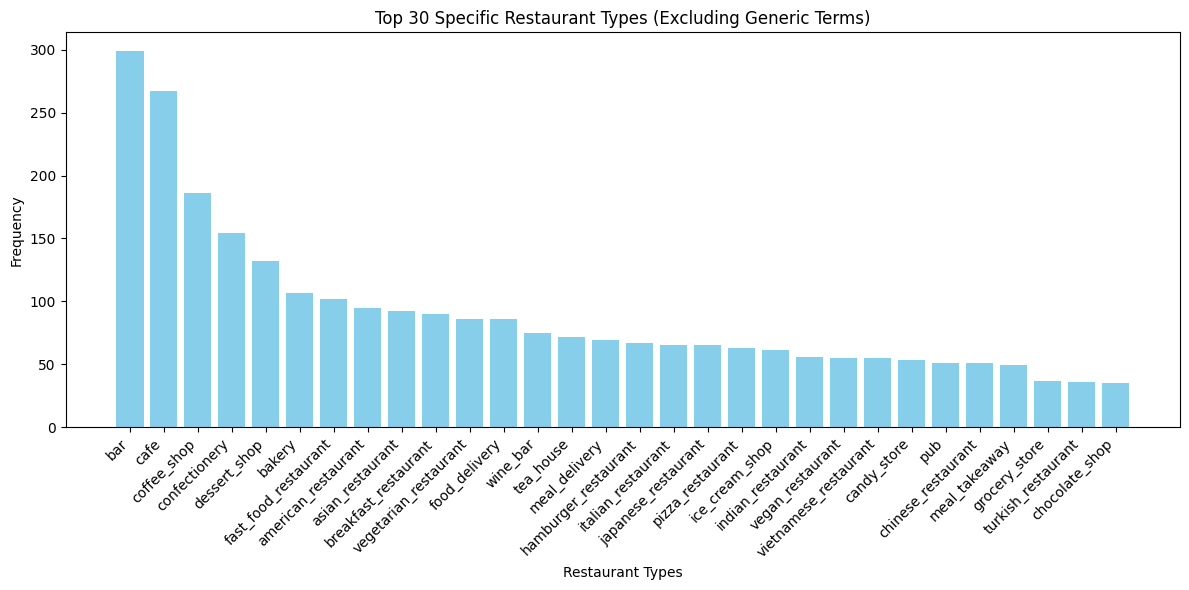

In [17]:
import matplotlib.pyplot as plt

exclude_terms = {'point_of_interest', 'establishment', 'food', 'restaurant', 'store', 'food_store'}

# Filter out the unwanted terms
filtered_types = {k: v for k, v in unique_types.items() if k not in exclude_terms}

# Sort by frequency and take the top 10 (or all if fewer than 10 remain)
top_n = 30
sorted_types = sorted(filtered_types.items(), key=lambda x: x[1], reverse=True)[:top_n]

# Extract types and frequencies
types = [item[0] for item in sorted_types]
frequencies = [item[1] for item in sorted_types]

# Create the bar plot
plt.figure(figsize=(12, 6))  # Wider figure for spacing
plt.bar(types, frequencies, color='skyblue')

# Customize the plot
plt.xlabel('Restaurant Types')
plt.ylabel('Frequency')
plt.title(f'Top {top_n} Specific Restaurant Types (Excluding Generic Terms)')
plt.xticks(rotation=45, ha='right')  # Rotate labels for readability

# Adjust layout and display
plt.tight_layout()
plt.show()

## Places reviews analysis

In this section we analyse scraped users reviews of fetched places.

### Frequency analysis
In this experiment we find out how many places different users rated. This will tell us if there is a significant sample of people who rated multiple places and based on which we could construct simple KNN recommendation system which would help us to overcome cold start problem.

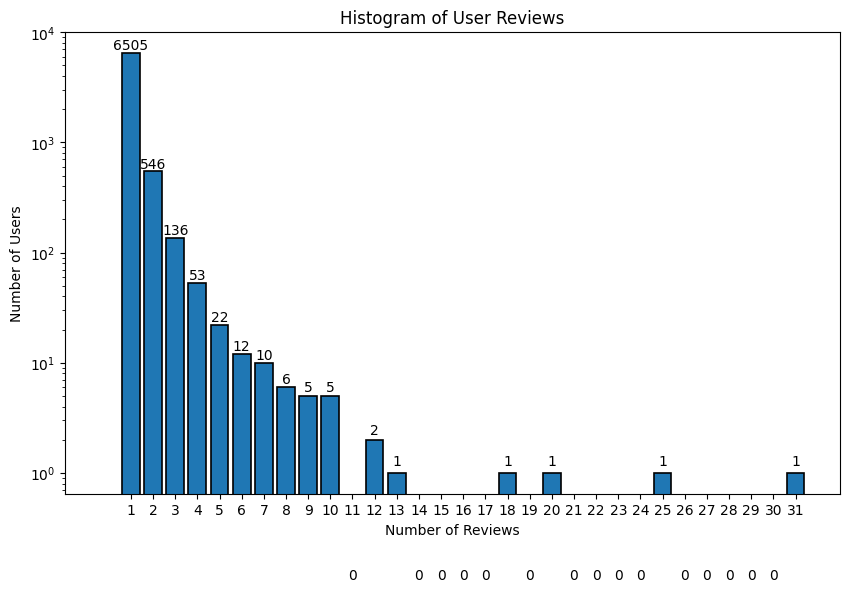

In [1]:
from users_ratings_frequencies import aggregate_user_reviews_scraped_data,aggregate_user_reviews_google_places_API, get_users_reviews_count_frequencies, plot_users_reviews_count_histogram


aggregated_authors_places = aggregate_user_reviews_google_places_API()
#aggregated_authors_places = aggregate_user_reviews_scraped_data()

reviews_frequencies = get_users_reviews_count_frequencies(aggregated_authors_places)

#plot_users_reviews_count_pie_chart(aggregated_authors_places)
plot_users_reviews_count_histogram(reviews_frequencies, 31)


## Total restaurant converage in top n super user
In this subsection, we analyse how many restaurants do the top n super users cover.


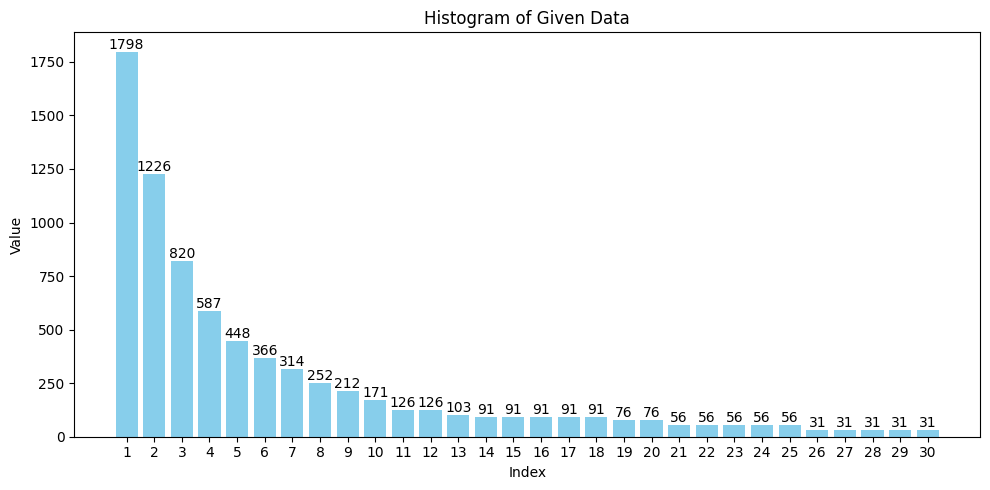

In [5]:
from users_ratings_frequencies import get_topn_users_coverage, plot_user_places_coverage_histogram, aggregate_user_reviews_google_places_API

aggregated_authors_places = aggregate_user_reviews_google_places_API()

topn_max = 31

res = []
for min_place_count in range(1, topn_max):
    res.append(len(get_topn_users_coverage(aggregated_authors_places, min_place_count)))

    
plot_user_places_coverage_histogram(res)



